#### What are the ***most demanded skills*** for the top 3 ***most popular data roles*** in India?

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Accessing raw data from data access function
from data_jobs.data_access import load_data

# Cleaning the data with cleaning function/s
from data_jobs.data_process import clean_date, clean_skills


df = load_data()
df = clean_date(df)
df = clean_skills(df)

print("Lib/s loaded and data ready")

Lib/s loaded and data ready


In [ ]:
# country of interest
df_IN = df.query('job_country == "India"')

In [3]:
df_skills = df_IN.explode('job_skills')

df_skills[['job_title_short','job_skills']]

,job_title_short,job_skills
16,Data Engineer,powershell
16,Data Engineer,python
16,Data Engineer,sql
16,Data Engineer,mysql
16,Data Engineer,sql server
...,...,...
785716,Software Engineer,c#
785716,Software Engineer,sql
785718,Business Analyst,NaN
785740,Software Engineer,aws


In [ ]:
df_skills_count = df_skills.groupby(['job_skills',
                                     'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count




,job_skills,job_title_short,skill_count
0,airflow,Business Analyst,19
1,airflow,Cloud Engineer,29
2,airflow,Data Analyst,89
3,airflow,Data Engineer,2990
4,airflow,Data Scientist,327
...,...,...,...
1684,zoom,Data Scientist,32
1685,zoom,Senior Data Analyst,1
1686,zoom,Senior Data Engineer,14
1687,zoom,Senior Data Scientist,4


In [ ]:
# listing our 3 most popular data roles.
df_skills_count.sort_values(by='skill_count', ascending=False, 
                            inplace=True)

job_titles = df_skills_count['job_title_short'].unique().tolist()
top_titles = sorted(job_titles[:3])
top_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

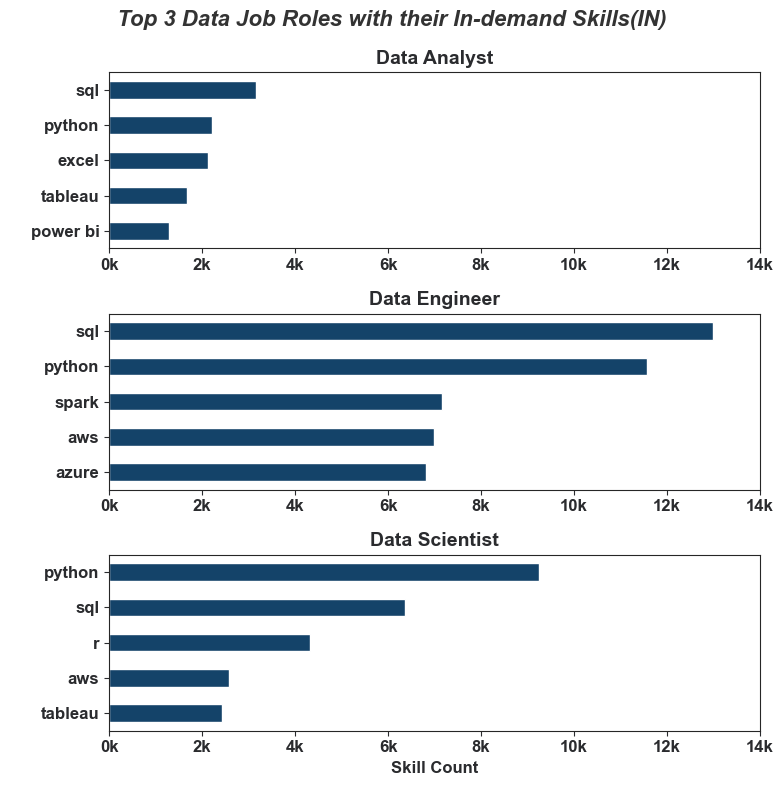

In [70]:
plt.rcParams.update({ 'font.weight': 'bold',
                     'font.size': 12,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'axes.labelcolor': "#2A2B2E",
    'text.color': '#2A2B2E',
    'axes.titlecolor': '#2A2B2E',
    'xtick.color': "#2A2B2E",
    'ytick.color': '#2A2B2E',
    'axes.titlesize':14,
    'axes.labelsize':12
    })

fig, ax = plt.subplots(len(top_titles), 1, figsize=(8,8))

for i, job_title in enumerate(top_titles):
    df_plot = df_skills_count[df_skills_count
                              ['job_title_short'] == job_title].head()
    
    df_plot.plot(kind='barh', x='job_skills', 
                 y='skill_count', ax=ax[i], 
                 title=job_title, legend=False,
                 color="#144369"
                 )
    
    ax[i].invert_yaxis()
    ax[i].set_ylabel(' ')
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'{int(x/1000)}k'))
    ax[i].set_xlim(0, 14000)
    
ax[i].set_xlabel('Skill Count')

plt.suptitle('Top 3 Data Job Roles with their In-demand Skills(IN)', 
             fontsize=16, fontweight='bold', 
             color="#333333", fontstyle='italic')
plt.tight_layout()
plt.show()

In [ ]:
# converting data roles with their job count into df.
df_job_title_count = df_IN['job_title_short'].value_counts().reset_index(name='total_jobs')

df_job_title_count

,job_title_short,total_jobs
0,Data Engineer,19062
1,Data Scientist,13279
2,Data Analyst,6121
3,Senior Data Engineer,4353
4,Senior Data Scientist,2486
5,Business Analyst,1887
6,Software Engineer,1795
7,Senior Data Analyst,1083
8,Machine Learning Engineer,671
9,Cloud Engineer,351


In [ ]:
# merging the two dfs, different skills count and data roles count.
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, 
                          how='left', on='job_title_short')

# getting chances of each skills in each data roles.
df_skills_perc['skill_%'] = round(df_skills_perc['skill_count']
                                   / df_skills_perc['total_jobs']*100, 2)

df_skills_perc

,job_skills,job_title_short,skill_count,total_jobs,skill_%
0,sql,Data Engineer,12993,19062,68.16
1,python,Data Engineer,11568,19062,60.69
2,python,Data Scientist,9248,13279,69.64
3,spark,Data Engineer,7157,19062,37.55
4,aws,Data Engineer,6993,19062,36.69
...,...,...,...,...,...
1684,angular.js,Data Scientist,1,13279,0.01
1685,arch,Business Analyst,1,1887,0.05
1686,mlpack,Data Engineer,1,19062,0.01
1687,yarn,Senior Data Scientist,1,2486,0.04


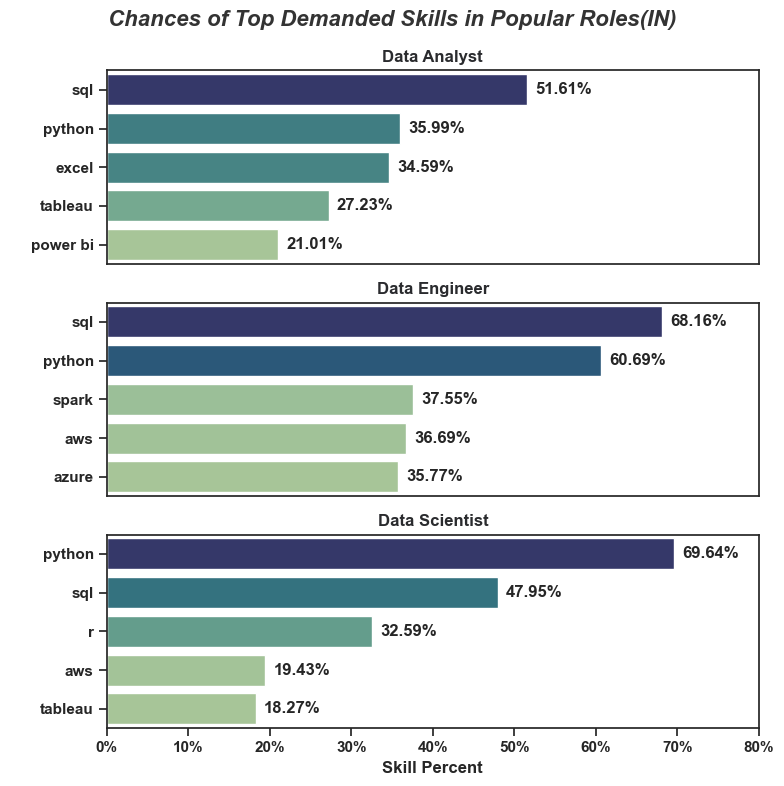

In [102]:
fig, ax = plt.subplots(len(top_titles), 1, figsize=(8,8))
sns.set_style("ticks")


for i, job_title in enumerate(top_titles):
    df_plot = df_skills_perc[df_skills_perc
                              ['job_title_short'] == job_title].head()
    
    sns.barplot(data=df_plot, x='skill_%', 
                y='job_skills', ax=ax[i], 
                hue='skill_count', palette='crest', 
                legend=False)
    ax[i].set_title(job_title)
    ax[i].set_ylabel(' ')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0, 80)
    ax[i].set_xticks([])

    for n, v in enumerate(df_plot['skill_%']):
        ax[i].text(v+1, n, f'{v}%', va='center')

ax[-1].set_xticks(range(0, 81, 10))
ax[-1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'{int(x)}%')
    )
ax[-1].set_xlabel('Skill Percent')

plt.suptitle('Chances of Top Demanded Skills in Popular Roles(IN)', 
             fontsize=16, fontweight='bold', 
             color="#333333", fontstyle='italic')
plt.tight_layout()
plt.show()